# Task 2: Support Vector Machine (SVM) for Classification
 Dataset: House Prediction Data Set
 Tools: Python, pandas, scikit-learn, matplotlib

In [2]:
#import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
# -----------------------------
# 1. Load the dataset
# -----------------------------
columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX",
    "PTRATIO","B","LSTAT","MEDV"
]
df = pd.read_csv("house Prediction Data Set.csv", delim_whitespace=True, names=columns)

print("First 5 rows of dataset:")
df.head()


First 5 rows of dataset:


C:\Users\sammy\AppData\Local\Temp\ipykernel_22076\3438684215.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("house Prediction Data Set.csv", delim_whitespace=True, names=columns)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# -----------------------------
# 2. Define Binary Target
# -----------------------------
median_price = df['MEDV'].median()
df['Price_High'] = (df['MEDV'] >= median_price).astype(int)

X = df.drop(['MEDV','Price_High'], axis=1)
y = df['Price_High']


In [ ]:
# -----------------------------
# 3. Standardize Features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
#-----------------------------
# 4. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


--- SVM with linear kernel ---
Accuracy: 0.8725490196078431
Precision: 0.88
Recall: 0.8627450980392157
Confusion Matrix:
 [[45  6]
 [ 7 44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87        51
           1       0.88      0.86      0.87        51

    accuracy                           0.87       102
   macro avg       0.87      0.87      0.87       102
weighted avg       0.87      0.87      0.87       102


--- SVM with rbf kernel ---
Accuracy: 0.8725490196078431
Precision: 0.8958333333333334
Recall: 0.8431372549019608
Confusion Matrix:
 [[46  5]
 [ 8 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88        51
           1       0.90      0.84      0.87        51

    accuracy                           0.87       102
   macro avg       0.87      0.87      0.87       102
weighted avg       0.87      0.87      0.87       102



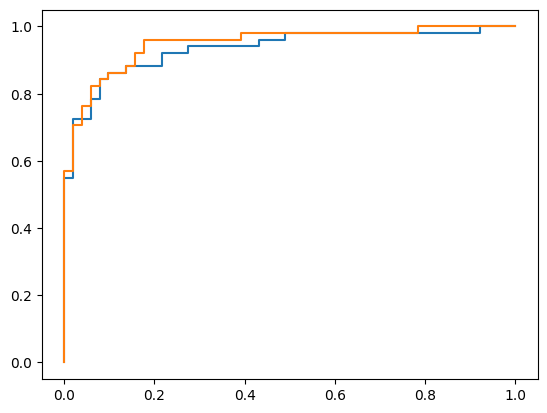

In [7]:
# -----------------------------
# 5. Train SVM with Different Kernels
# -----------------------------
for kernel in ['linear', 'rbf']:
    print(f"\n--- SVM with {kernel} kernel ---")
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train, y_train)

    # Predictions
    y_pred = svm.predict(X_test)

    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # ROC Curve
    y_prob = svm.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{kernel} kernel (AUC = {roc_auc:.2f})")

C:\Users\sammy\AppData\Local\Temp\ipykernel_22076\2181823094.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


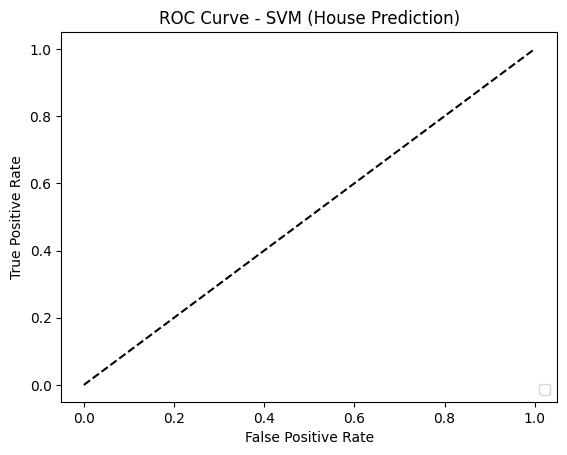

In [8]:
# -----------------------------
# 6. Final ROC Plot
# -----------------------------
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (House Prediction)")
plt.legend(loc="lower right")
plt.show()


# -----------------------------COMPLETED------------------------------
---------------------------------------------------------------------------LEVEL 3-TASK 2-----------------------------------------------------------------------------